In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [18]:
import pandas as pd
from pybaseball import statcast_pitcher
from pybaseball import pitching_stats
from pybaseball import playerid_lookup
from pybaseball import playerid_reverse_lookup
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [37]:
# creates dataframe of pitching profiles, including IDs
yearly_dfs = []
for year in range(2016, 2026):
    leaderboard = pitching_stats(year)  
    yearly_df = leaderboard[['IDfg', 'Season', 'FB% 2', 'FBv', 'SL%', 'SLv', 'CT%', 'CTv', 'CB%', 'CBv', 'CH%', 'CHv']]
    yearly_df = yearly_df.fillna(0)
    yearly_dfs.append(yearly_df)
profile_dfs = pd.concat(yearly_dfs, ignore_index=True)

In [27]:
# Creates and processes 2015-2023 dataset
#id_list = qualifiedPitchers()
#p_dfs = buildDatasets(id_list)

In [ ]:
# builds list of lists including pitcher seasons and f1 scores
p_f1s = []
for p in p_dfs:
    f1 = f1FromRF(p[2])
    p_f1s.append([p[0], p[1], f1])
    print("RF model built")

RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model built
RF model b

In [4]:
# takes a dataset, builds random forest model, and computes f1 score
def f1FromRF(df):
    target = "pitch_type"
    X = df.drop(columns=[target])
    y = df[target]
    categorical_cols = ["stand", "lag_pitch", "lag_pitch2"]
    X = pd.get_dummies(X, columns=categorical_cols)
    le = LabelEncoder()
    y = le.fit_transform(y)
    split_index = int(len(X) * (1/3))
    X_test  = X.iloc[:split_index]
    X_train = X.iloc[split_index:]
    y_test  = y[:split_index]
    y_train = y[split_index:]
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight="balanced",
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    return macro_f1

In [25]:
# loading saved RF dataframes
with open("mlb_data.pkl", "rb") as f:
    p_dfs = pickle.load(f)

In [24]:
# saving loaded RF dataframes
with open("mlb_data.pkl", "wb") as f:
    pickle.dump(p_dfs, f)

In [5]:
# loading saved profile dataframes
with open("p_profiles.pkl", "rb") as f:
    profile_dfs = pickle.load(f)

In [20]:
# saving loaded profile dataframes
with open("p_profiles.pkl", "wb") as f:
    pickle.dump(profile_dfs, f)

In [32]:
# loading saved f1 scores
with open("f1_scores.pkl", "rb") as f:
    p_f1s = pickle.load(f)

In [31]:
# saving loaded f1 scores
with open("f1_scores.pkl", "wb") as f:
    pickle.dump(p_f1s, f)

In [38]:
# This code block clusters pitchers by k-means.  I would like to improve the quality of my clustering later with hyperparameter tuning
# scale and cluster data
c_data = profile_dfs.drop(columns=['IDfg', 'Season'])
scaler = StandardScaler()
c_data_scaled = scaler.fit_transform(c_data)
kmeans = KMeans(n_clusters=5, random_state=100, n_init=10)
kmeans.fit(c_data_scaled)
# this adds the cluster labels to the profile dataset
profile_dfs['cluster'] = kmeans.labels_

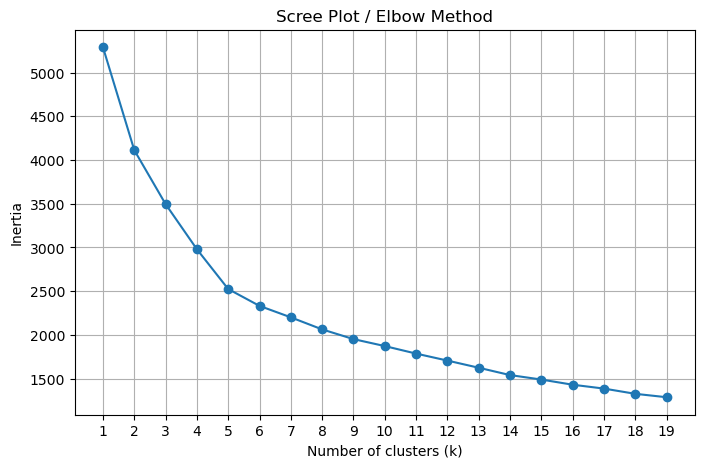

In [27]:
# building scree plot to determine optimal number of clusters
cluster_range = range(1, 20)
inertia_values = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=100, n_init=10)
    kmeans.fit(c_data_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(cluster_range, inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Scree Plot / Elbow Method')
plt.xticks(cluster_range)
plt.grid(True)
plt.show()

In [22]:
# pulls array containing pitcher IDs and season # for qualified pitchers (162 innings thrown)
def qualifiedPitchers():
    id_list = []
    for year in range(2015, 2026):
        qual_pitcher = pitching_stats(year)
        id_list_ind = qual_pitcher.iloc[:, 0].values.tolist()
        mlbam_ids = fgToMlbam(id_list_ind)
        for i in mlbam_ids:
            id_list.append([i, year])
    return id_list

In [8]:
# converts Fangraph IDs to MLBAM IDs
def fgToMlbam(id_list):
    all_p_ids = playerid_reverse_lookup(id_list, key_type='fangraphs')
    mlbam_ids = all_p_ids['key_mlbam'].values
    return mlbam_ids

In [28]:
# preparing dataset to include all random forests
def prepareForRF(dataset):
    dataset = dataset[dataset["game_type"] == "R"].copy()
    dataset = dataset[['pitch_type', 'balls', 'strikes', 'stand', 'inning', 'outs_when_up', 'on_1b', 'on_2b', 'on_3b']].copy()
    dataset["lag_pitch"] = dataset["pitch_type"].shift(-1)
    dataset["lag_pitch2"] = dataset["pitch_type"].shift(-2)
    dataset["br1"] = dataset["on_1b"].notna().astype(int)
    dataset["br2"] = dataset["on_2b"].notna().astype(int)
    dataset["br3"] = dataset["on_3b"].notna().astype(int)
    dataset = dataset.drop(columns=["on_1b", "on_2b", "on_3b"])
    datasetRF = dataset[(dataset["strikes"] == 2) | ((dataset["strikes"] == 1) & (dataset["balls"] == 3))].copy()
    return datasetRF

In [10]:
# Creates nested array carrying ID and correlated prepared dataset
def buildDatasets(id_list): 
    pitcher_dfs = []
    for p_season in id_list:
        pitcher_df = statcast_pitcher(f'{p_season[1]}-03-10', f'{p_season[1]}-08-10', p_season[0])
        print(p_season[0])
        print(p_season[1])
        pitcher_df = prepareForRF(pitcher_df)
        pitcher_dfs.append([p_season[0], p_season[1], pitcher_df])
    return pitcher_dfs